<a href="https://colab.research.google.com/github/Harshitha1024/gold-price-prediction/blob/main/pa_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance statsmodels tensorflow scikit-learn

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [5]:
ticker = 'AAPL' # Example ticker
start_date = '2020-01-01'
end_date = '2023-01-01'
data = yf.download(ticker, start=start_date, end=end_date)['Close'].values.reshape(-1, 1)

train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

/tmp/ipykernel_11951/3322694446.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)['Close'].values.reshape(-1, 1)
[*********************100%***********************]  1 of 1 completed


In [6]:
model_arima = ARIMA(train, order=(5,1,0))  # (p,d,q)
model_arima_fit = model_arima.fit()

# Forecast
arima_pred = model_arima_fit.forecast(steps=len(test))

In [7]:
mae_arima = mean_absolute_error(test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))
r2_arima = r2_score(test, arima_pred)

print("ARIMA Performance:")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("R2:", r2_arima)

ARIMA Performance:
MAE: 10.442459890973169
RMSE: 13.357928729093354
R2: -0.6400924749443602


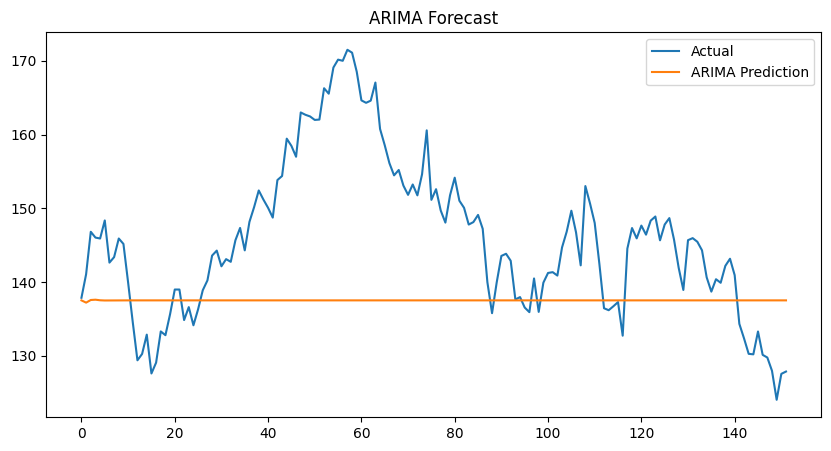

In [9]:
plt.figure(figsize=(10,5))
plt.plot(range(len(test)), test, label='Actual')
plt.plot(range(len(test)), arima_pred, label='ARIMA Prediction')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [10]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [13]:
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [14]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model_lstm.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=10, batch_size=32)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0823 - val_loss: 0.0156
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0075 - val_loss: 0.0044
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0034 - val_loss: 0.0039
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0025 - val_loss: 0.0031
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0019 - val_loss: 0.0034
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - loss: 0.0018 - val_loss: 0.0028


In [16]:
lstm_pred = model_lstm.predict(X_test)

# Inverse transform
lstm_pred = scaler.inverse_transform(lstm_pred.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step


In [17]:
mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
r2_lstm = r2_score(y_test_actual, lstm_pred)

print("LSTM Performance:")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("R2:", r2_lstm)

LSTM Performance:
MAE: 5.590423803535296
RMSE: 6.526777604134603
R2: 0.6280701586995572


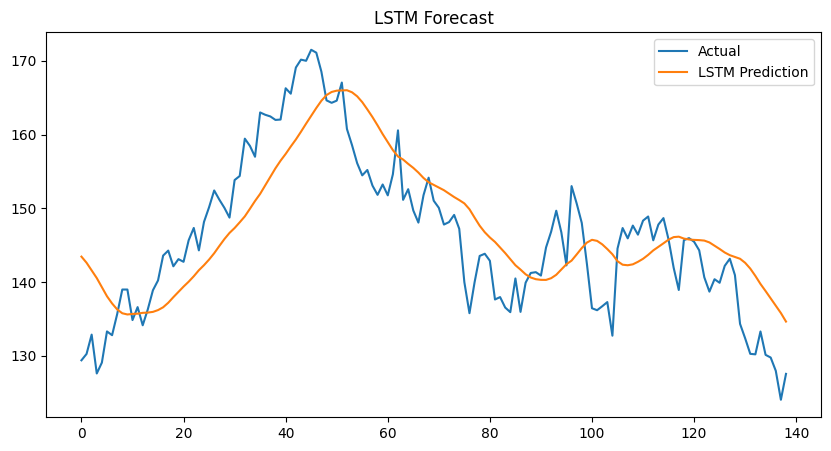

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Prediction')
plt.legend()
plt.title("LSTM Forecast")
plt.show()

In [19]:
print("\nModel Comparison:")
print("ARIMA RMSE:", rmse_arima)
print("LSTM RMSE:", rmse_lstm)


Model Comparison:
ARIMA RMSE: 13.357928729093354
LSTM RMSE: 6.526777604134603
